# Chapter 2 / §7 Pandas & NumPy 基础作业

姓名：__________  
日期：__________

本 Notebook 完成 §7.1 基础作业与 §7.2 拓展练习，包含文字回答、代码、运行结果和图表。

## §7.1 基础作业

### 1. Python 环境安装与配置

（1）已在本地计算机安装 Anaconda、Jupyter Notebook、VS Code，并成功运行第一个 Hello Python 程序。示例代码如下：

In [1]:
print('Hello Python')

Hello Python


（2）使用 Conda 创建独立虚拟环境，并为 Jupyter 配置 Kernel 的常用流程如下：

```bash
conda create -n data-mining python=3.11
conda activate data-mining
pip install numpy pandas matplotlib seaborn scikit-learn ipykernel
python -m ipykernel install --user --name data-mining --display-name "Python (data-mining)"
```

这样可以在 Jupyter Notebook 中选择不同 Kernel，使不同项目使用相互独立的依赖环境，避免包版本冲突。

### 2. 概念与理解题

#### （1）NumPy 和 Pandas 的角色

NumPy 更偏向“数值计算底层工具”。它提供高效的多维数组 `ndarray`，适合做矩阵运算、向量化计算、随机数模拟、线性代数等工作。很多机器学习和科学计算库都以 NumPy 数组作为基础数据结构。

Pandas 更偏向“表格数据处理工具”。它提供 `Series` 和 `DataFrame`，适合处理带行列标签的数据，例如 CSV、Excel、数据库表等。Pandas 在数据清洗、筛选、分组统计、缺失值处理、时间序列处理等任务中更方便。

更倾向使用 NumPy 数组的情况：数据结构规则、主要是纯数值矩阵或向量；更关心计算速度和数学运算；需要直接输入到机器学习模型或数值算法中。

更倾向使用 Pandas DataFrame 的情况：数据是表格形式，包含列名、类别变量、缺失值等；需要频繁进行筛选、排序、分组、聚合、连接、统计描述；需要更直观地查看和理解数据。

#### （2）Pandas 操作含义

- `df.loc[0:10, ['age', 'score']]`：使用标签索引选择行标签从 0 到 10 的记录，并只取 `age` 和 `score` 两列。注意 `loc` 的切片通常包含结束标签 10。
- `df[df['age'] > 20]`：筛选出 `age` 大于 20 的所有行，返回满足条件的子 DataFrame。
- `df.groupby('gender')['score'].mean()`：先按照 `gender` 分组，然后计算每个性别组中 `score` 的平均值。

### 3. 代码实践题：Pandas & NumPy 基础操作

#### （1）Wine 数据集分析

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_wine, load_iris

sns.set_theme(style="whitegrid")

wine = load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
df_wine['target'] = wine.target
df_wine['target_name'] = df_wine['target'].map(dict(enumerate(wine.target_names)))

cols = ['alcohol', 'malic_acid', 'color_intensity', 'hue', 'proline']
df_wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


In [3]:
df_wine[cols].describe()

,alcohol,malic_acid,color_intensity,hue,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,5.058090,0.957449,746.893258
std,0.811827,1.117146,2.318286,0.228572,314.907474
min,11.030000,0.740000,1.280000,0.480000,278.000000
25%,12.362500,1.602500,3.220000,0.782500,500.500000
50%,13.050000,1.865000,4.690000,0.965000,673.500000
75%,13.677500,3.082500,6.200000,1.120000,985.000000
max,14.830000,5.800000,13.000000,1.710000,1680.000000


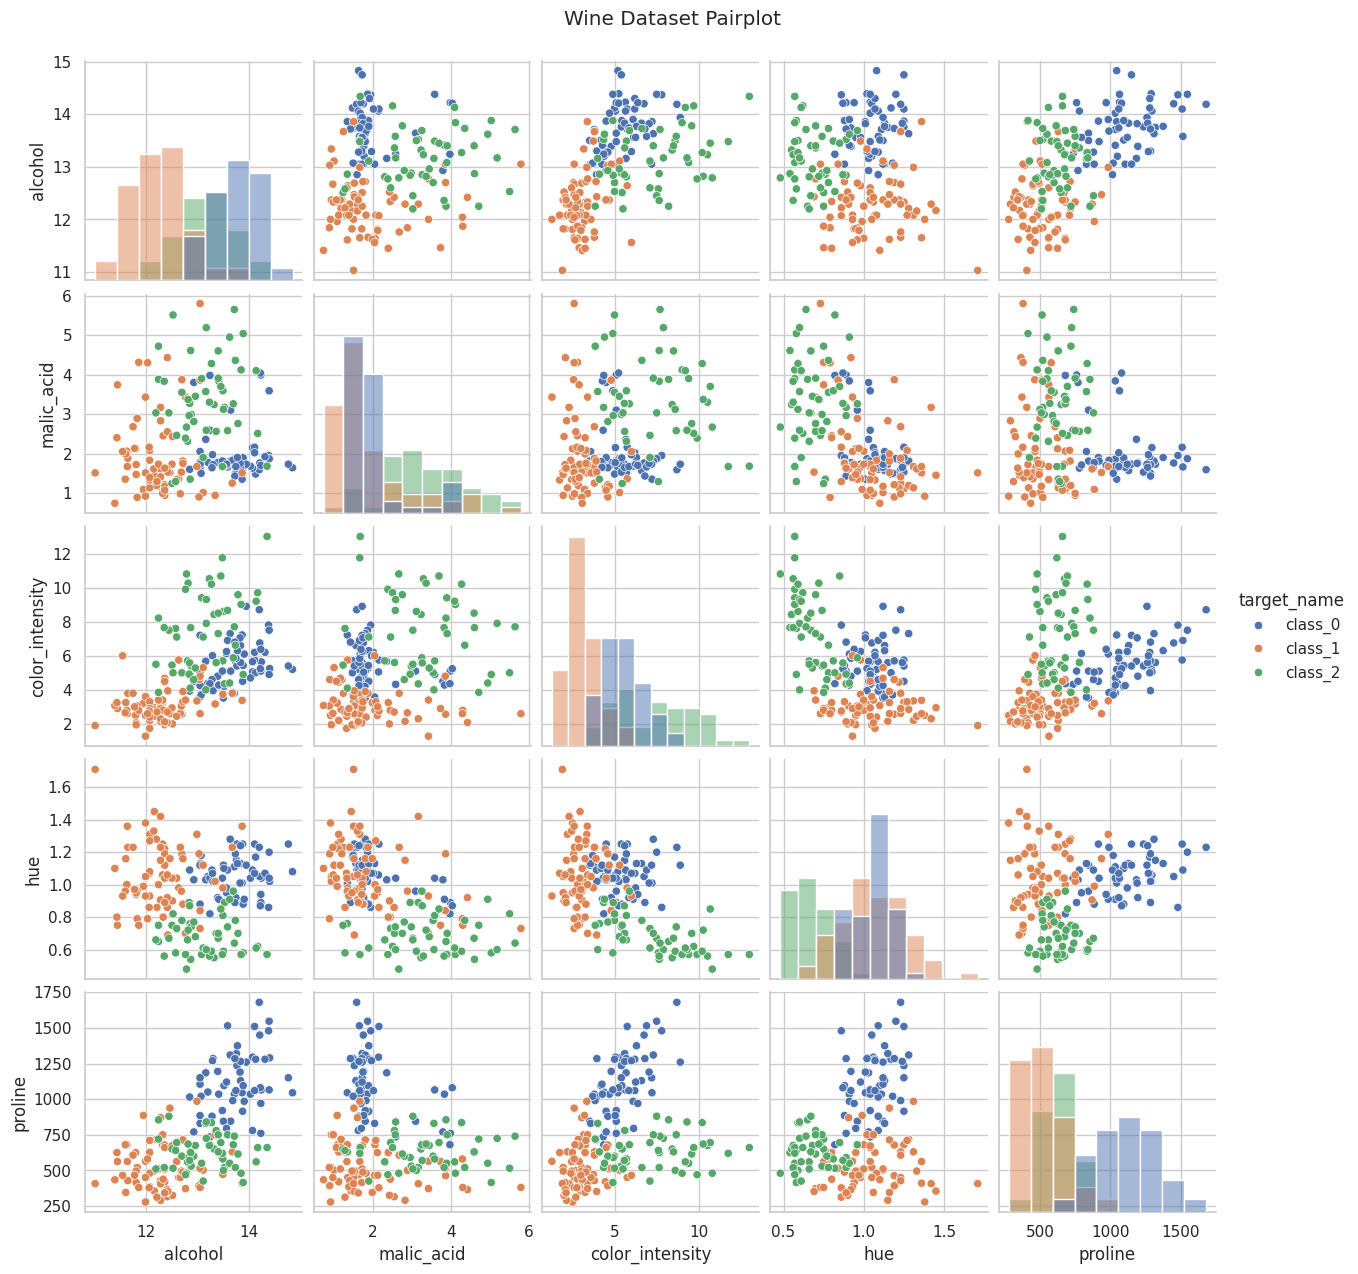

In [4]:
pair = sns.pairplot(df_wine[cols + ['target_name']], hue='target_name', diag_kind='hist')
pair.fig.suptitle('Wine Dataset Pairplot', y=1.02)
plt.show()

#### Wine 数据集观察

1. `proline` 的数值范围明显大于其他特征，说明不同特征之间存在明显的尺度差异，后续建模前通常需要考虑标准化。
2. 从散点图看，`color_intensity`、`hue`、`proline` 对不同类别有一定区分度，部分类别在这些特征上的分布区域较明显。
3. `alcohol` 与 `proline` 的组合对部分酒类类别区分较明显，高 `proline`、较高 `alcohol` 的样本更集中在某一类中。
4. 不同类别之间并不是所有特征都能完全线性分开，因此分类模型通常需要综合多个特征，而不是只依赖单一变量。

#### （2）使用 NumPy 手动实现标准化函数

In [5]:
def standardize(x):
    """输入一维 numpy 数组 x，输出标准化后的数组 (x - 均值) / 标准差。"""
    x = np.asarray(x, dtype=float)
    mean = x.mean()
    std = x.std()
    if std == 0:
        raise ValueError("标准差为 0，无法进行标准化。")
    return (x - mean) / std

alcohol_array = df_wine['alcohol'].to_numpy()
alcohol_std = standardize(alcohol_array)

print("标准化后均值：", alcohol_std.mean())
print("标准化后标准差：", alcohol_std.std())
print("前 5 个标准化结果：", alcohol_std[:5])

标准化后均值： -8.382807556720283e-16
标准化后标准差： 1.0
前 5 个标准化结果： [1.51861254 0.24628963 0.19687903 1.69154964 0.29570023]


### 4. 思考题：特征尺度与建模

Wine 数据集中不同化学成分的量纲差异很大。如果直接把原始特征输入分类模型，数值范围较大的特征可能在模型中占据更大影响。例如 `proline` 的数值远大于 `alcohol`，某些模型可能会把这种“数值大”误当成“更重要”，从而影响距离计算、梯度更新或正则化效果。

标准化 / 归一化的目的，是把不同特征放到相近的尺度上，让模型更公平地利用各个变量。标准化通常把数据变成均值为 0、标准差为 1 的分布；归一化常把数据缩放到 `[0, 1]` 或类似区间。这样可以提高训练稳定性，加快收敛，也可以避免某些特征因为量纲大而主导模型。

对特征尺度非常敏感的模型例子：KNN、K-Means、SVM、逻辑回归、神经网络等。其中 KNN 和 K-Means 尤其明显，因为它们直接依赖样本之间的距离。如果一个特征的数值范围特别大，它会显著影响距离计算结果。

## §7.2 拓展练习

### 1. 应用到 Iris 数据集

In [6]:
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris['target'] = iris.target
df_iris['target_name'] = df_iris['target'].map(dict(enumerate(iris.target_names)))

df_iris.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [7]:
df_iris.groupby('target_name')[iris.feature_names].mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
target_name,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


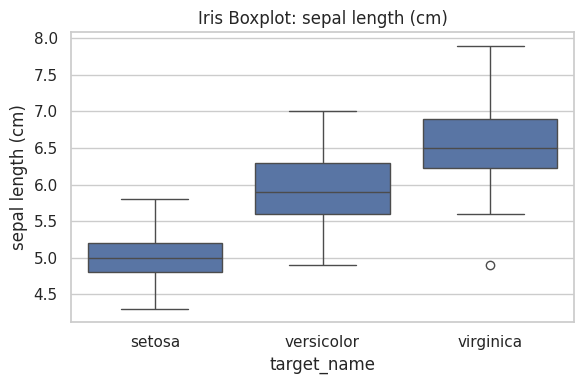

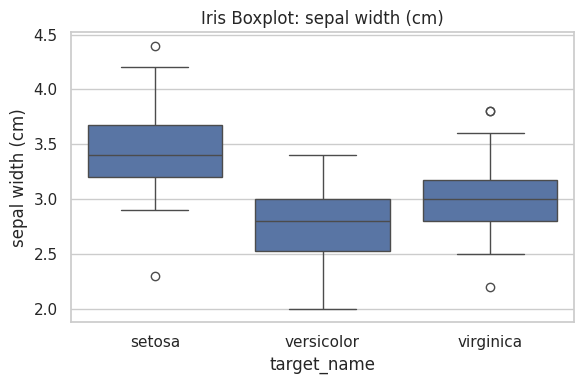

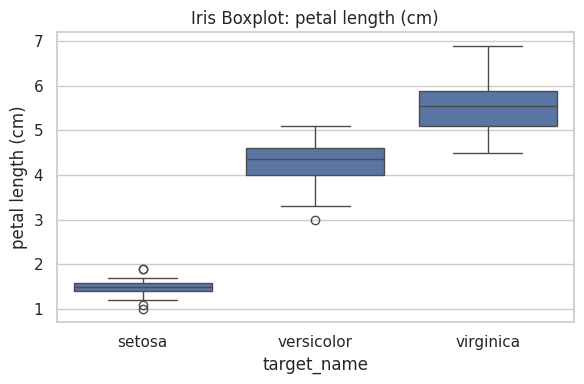

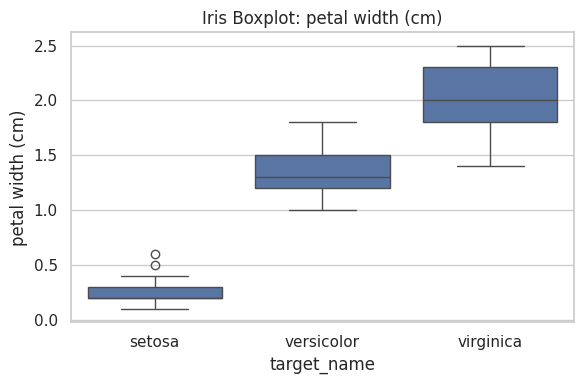

In [8]:
for feature in iris.feature_names:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_iris, x='target_name', y=feature)
    plt.title(f'Iris Boxplot: {feature}')
    plt.xlabel('target_name')
    plt.ylabel(feature)
    plt.tight_layout()
    plt.show()

#### Iris 数据集观察

从均值表和箱线图看，`petal length (cm)` 与 `petal width (cm)` 对类别区分最明显。Setosa 的花瓣长度和花瓣宽度明显小于另外两类，几乎可以直接区分出来。Versicolor 与 Virginica 在花瓣特征上仍有重叠，但差异比萼片特征更清楚。相比之下，`sepal length (cm)` 有一定帮助，而 `sepal width (cm)` 的类别重叠较多，单独用于分类的效果可能较弱。

### 2. 数据读取拓展：公开 CSV 数据集迷你 EDA

这里选择一个经典小型公开数据集：Seaborn 官方示例数据集中的 `tips.csv`（餐厅小费数据）。为了保证本 Notebook 在离线环境中也能运行，下面先把一个小型 CSV 样本写入本地文件，再使用 `pd.read_csv()` 读取。

In [9]:
from pathlib import Path

csv_text = """total_bill,tip,sex,smoker,day,time,size
16.99,1.01,Female,No,Sun,Dinner,2
10.34,1.66,Male,No,Sun,Dinner,3
21.01,3.50,Male,No,Sun,Dinner,3
23.68,3.31,Male,No,Sun,Dinner,2
24.59,3.61,Female,No,Sun,Dinner,4
25.29,4.71,Male,No,Sun,Dinner,4
8.77,2.00,Male,No,Sun,Dinner,2
26.88,3.12,Male,No,Sun,Dinner,4
15.04,1.96,Male,No,Sun,Dinner,2
14.78,3.23,Male,No,Sun,Dinner,2
10.27,1.71,Male,No,Sun,Dinner,2
35.26,5.00,Female,No,Sun,Dinner,4
15.42,1.57,Male,No,Sun,Dinner,2
18.43,3.00,Male,No,Sun,Dinner,4
14.83,3.02,Female,No,Sun,Dinner,2
21.58,3.92,Male,No,Sun,Dinner,2
10.33,1.67,Female,No,Sun,Dinner,3
16.29,3.71,Male,No,Sun,Dinner,3
16.97,3.50,Female,No,Sun,Dinner,3
20.65,3.35,Male,No,Sat,Dinner,3
17.92,4.08,Male,No,Sat,Dinner,2
20.29,2.75,Female,No,Sat,Dinner,2
15.77,2.23,Female,No,Sat,Dinner,2
39.42,7.58,Male,No,Sat,Dinner,4
19.82,3.18,Male,No,Sat,Dinner,2
17.81,2.34,Male,No,Sat,Dinner,4
13.37,2.00,Male,No,Sat,Dinner,2
12.69,2.00,Male,No,Sat,Dinner,2
21.70,4.30,Male,No,Sat,Dinner,2
19.65,3.00,Female,No,Sat,Dinner,2
9.55,1.45,Male,No,Sat,Dinner,2
18.35,2.50,Male,No,Sat,Dinner,4
15.06,3.00,Female,No,Sat,Dinner,2
20.69,2.45,Female,No,Sat,Dinner,4
17.78,3.27,Male,No,Sat,Dinner,2
24.06,3.60,Male,No,Sat,Dinner,3
16.31,2.00,Male,No,Sat,Dinner,3
16.93,3.07,Female,No,Sat,Dinner,3
18.69,2.31,Male,No,Sat,Dinner,3
31.27,5.00,Male,No,Sat,Dinner,3
16.04,2.24,Male,No,Sat,Dinner,3
17.46,2.54,Male,No,Sun,Dinner,2
13.94,3.06,Male,No,Sun,Dinner,2
9.68,1.32,Male,No,Sun,Dinner,2
30.40,5.60,Male,No,Sun,Dinner,4
18.29,3.00,Male,No,Sun,Dinner,2
22.23,5.00,Male,No,Sun,Dinner,2
32.40,6.00,Male,No,Sun,Dinner,4
28.55,2.05,Male,No,Sun,Dinner,3
18.04,3.00,Male,No,Sun,Dinner,2
"""

csv_path = Path('tips_public_sample.csv')
csv_path.write_text(csv_text, encoding='utf-8')

df_tips = pd.read_csv(csv_path)
df_tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  50 non-null     float64
 1   tip         50 non-null     float64
 2   sex         50 non-null     object 
 3   smoker      50 non-null     object 
 4   day         50 non-null     object 
 5   time        50 non-null     object 
 6   size        50 non-null     int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 2.9+ KB


In [11]:
df_tips.describe()

,total_bill,tip,size
count,50.000000,50.000000,50.000000
mean,19.231200,3.089600,2.700000
std,6.678628,1.297168,0.814411
min,8.770000,1.010000,2.000000
25%,15.150000,2.095000,2.000000
50%,17.980000,3.000000,2.000000
75%,21.670000,3.575000,3.000000
max,39.420000,7.580000,4.000000


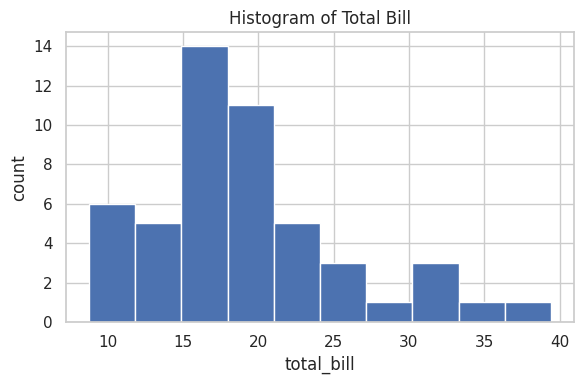

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(df_tips['total_bill'], bins=10)
plt.title('Histogram of Total Bill')
plt.xlabel('total_bill')
plt.ylabel('count')
plt.tight_layout()
plt.show()

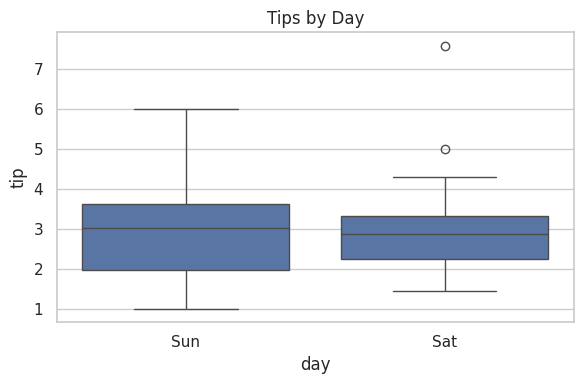

In [13]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_tips, x='day', y='tip')
plt.title('Tips by Day')
plt.xlabel('day')
plt.ylabel('tip')
plt.tight_layout()
plt.show()

#### 迷你 EDA 报告（不超过 200 字）

这个数据集记录了餐厅消费账单、小费、用餐人数、日期、性别、是否吸烟、午餐/晚餐等信息。比较有意思的特征是 `total_bill`、`tip` 和 `size`，因为它们能反映消费金额、小费金额与同行人数之间的关系。从直方图看，大多数账单金额集中在较低区间，少数账单较高。从箱线图看，不同日期的小费分布存在差异。该数据集适合做回归任务，例如根据账单金额、人数、日期等预测小费；也可做简单聚类或消费行为分析。